In [1]:

import numpy as np
import stim
import torch
import pymatching
from collections import OrderedDict
from torch import nn, optim
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, Subset
import simulated_annealing

In [2]:
def generate_dem_XY(noise_model, code_distance, noise_param):
    if noise_model == 'DP':
        circuit = stim.Circuit.generated(
            "surface_code:rotated_memory_z", # Protect a qubit stored in the z basis to detect a bit flip (logical x error)
            rounds=9,
            distance=code_distance,
            before_round_data_depolarization=noise_param
        )
    elif noise_model == 'FT':
        circuit = stim.Circuit.generated(
            "surface_code:rotated_memory_z", # Protect a qubit stored in the z basis to detect a bit flip (logical x error)
            rounds=9,
            distance=code_distance,
            after_clifford_depolarization=noise_param, # Circuit-level (FT) noise
            after_reset_flip_probability=noise_param, # Circuit-level (FT) noise
            before_measure_flip_probability=noise_param, # Circuit-level (FT) noise
            before_round_data_depolarization=noise_param
        )

    dem = circuit.detector_error_model(decompose_errors=True)
    sampler = circuit.compile_detector_sampler(seed=42)

    n_shots = 1_000_000
    syndromes, obs = sampler.sample(shots=n_shots, separate_observables=True)

    # Converting to numerical numbers for computations 
    labels = obs.astype(np.float32)
    features = syndromes.astype(np.float32)
    #print(obs.shape)
    #print(len(features))
    # From numpy to torch
    labels = torch.from_numpy(labels)
    features = torch.from_numpy(features)

    return dem, features, labels, syndromes, obs

In [3]:
# Depolarizing d = 3, noise_param = 0.005

dem_d3_005_DP, X_d3_005_DP, Y_d3_005_DP, synds_d3_005_DP, obs_d3_005_DP  = generate_dem_XY('DP', 3, 0.005)

# Neural Network Model
input_size = 72 # N_rounds = 9, N_ancillas = 8 (for distance=3)
output_size = 1
hidden_sizes = (512, 256, 128, 64)
dropout_p = [.3, 0.0, .1, .1]
model_d3_005_DP = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(input_size, hidden_sizes[0])),
            ('relu1', nn.ReLU()),
            ('drp1', nn.Dropout(dropout_p[0])),
            ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
            ('relu2', nn.ReLU()),
            ('drp2', nn.Dropout(dropout_p[1])),
            ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
            ('relu3', nn.ReLU()),
            ('drp3', nn.Dropout(dropout_p[2])),
            ('fc4', nn.Linear(hidden_sizes[2], hidden_sizes[3])),
            ('relu4', nn.ReLU()),
            ('drp4', nn.Dropout(dropout_p[3])),
            ('fc5', nn.Linear(hidden_sizes[3], output_size)),
            ])
        )
state_dict = torch.load('depolarizing/model-d3-005.pth', map_location=torch.device('cpu'))
model_d3_005_DP.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_16328\1560084906.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('depolarizing/model-d3-005.pth', 

<All keys matched successfully>

In [4]:
# Depolarizing d = 3, noise_param = 0.01

dem_d3_01_DP, X_d3_01_DP, Y_d3_01_DP, synds_d3_01_DP, obs_d3_01_DP  = generate_dem_XY('DP', 3, 0.01)

# Neural Network Model
input_size = 72 # N_rounds = 9, N_ancillas = 8 (for distance=3)
output_size = 1
hidden_sizes = (512, 256, 128, 64)
dropout_p = [.3, 0.0, .1, .1]
model_d3_01_DP = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(input_size, hidden_sizes[0])),
            ('relu1', nn.ReLU()),
            ('drp1', nn.Dropout(dropout_p[0])),
            ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
            ('relu2', nn.ReLU()),
            ('drp2', nn.Dropout(dropout_p[1])),
            ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
            ('relu3', nn.ReLU()),
            ('drp3', nn.Dropout(dropout_p[2])),
            ('fc4', nn.Linear(hidden_sizes[2], hidden_sizes[3])),
            ('relu4', nn.ReLU()),
            ('drp4', nn.Dropout(dropout_p[3])),
            ('fc5', nn.Linear(hidden_sizes[3], output_size)),
            ])
        )
state_dict = torch.load('depolarizing/model-d3-01.pth', map_location=torch.device('cpu'))
model_d3_01_DP.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_16328\3767727586.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('depolarizing/model-d3-01.pth', m

<All keys matched successfully>

In [5]:
# Depolarizing d = 5, noise_param = 0.005

dem_d5_005_DP, X_d5_005_DP, Y_d5_005_DP, synds_d5_005_DP, obs_d5_005_DP = generate_dem_XY('DP', 5, 0.005)

# Neural Network Model
input_size = 216 # N_rounds = 9, N_ancillas = 24 (for distance=5)
output_size = 1
hidden_sizes = (512, 256, 128, 64)
dropout_p = [.3, 0.0, .1, .1]
model_d5_005_DP = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(input_size, hidden_sizes[0])),
            ('relu1', nn.ReLU()),
            ('drp1', nn.Dropout(dropout_p[0])),
            ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
            ('relu2', nn.ReLU()),
            ('drp2', nn.Dropout(dropout_p[1])),
            ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
            ('relu3', nn.ReLU()),
            ('drp3', nn.Dropout(dropout_p[2])),
            ('fc4', nn.Linear(hidden_sizes[2], hidden_sizes[3])),
            ('relu4', nn.ReLU()),
            ('drp4', nn.Dropout(dropout_p[3])),
            ('fc5', nn.Linear(hidden_sizes[3], output_size)),
            ])
        )
state_dict = torch.load('depolarizing/model-d5-005.pth', map_location=torch.device('cpu'))
model_d5_005_DP.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_16328\1555244240.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('depolarizing/model-d5-005.pth', 

<All keys matched successfully>

In [6]:
# Depolarizing d = 5, noise_param = 0.01

dem_d5_01_DP, X_d5_01_DP, Y_d5_01_DP, synds_d5_01_DP, obs_d5_01_DP = generate_dem_XY('DP', 5, 0.01)

# Neural Network Model
input_size = 216 # N_rounds = 9, N_ancillas = 24 (for distance=5)
output_size = 1
hidden_sizes = (512, 256, 128, 64)
dropout_p = [.3, 0.0, .1, .1]
model_d5_01_DP = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(input_size, hidden_sizes[0])),
            ('relu1', nn.ReLU()),
            ('drp1', nn.Dropout(dropout_p[0])),
            ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
            ('relu2', nn.ReLU()),
            ('drp2', nn.Dropout(dropout_p[1])),
            ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
            ('relu3', nn.ReLU()),
            ('drp3', nn.Dropout(dropout_p[2])),
            ('fc4', nn.Linear(hidden_sizes[2], hidden_sizes[3])),
            ('relu4', nn.ReLU()),
            ('drp4', nn.Dropout(dropout_p[3])),
            ('fc5', nn.Linear(hidden_sizes[3], output_size)),
            ])
        )
state_dict = torch.load('depolarizing/model-d5-01.pth', map_location=torch.device('cpu'))
model_d5_01_DP.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_16328\499478788.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('depolarizing/model-d5-01.pth', ma

<All keys matched successfully>

In [7]:
# Depolarizing d = 7, noise_param = 0.005

dem_d7_005_DP, X_d7_005_DP, Y_d7_005_DP, synds_d7_005_DP, obs_d7_005_DP = generate_dem_XY('DP', 7, 0.005)

# Neural Network Model
input_size = 432 # N_rounds = 9, N_ancillas = 48 (for distance=5)
output_size = 1
hidden_sizes = ( 1024, 512, 256, 128, 64)
dropout_p = [.2, .3, 0, .3, 0]
model_d7_005_DP = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(input_size, hidden_sizes[0])),
            ('relu1', nn.ReLU()),
            ('drp1', nn.Dropout(dropout_p[0])),
            ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
            ('relu2', nn.ReLU()),
            ('drp2', nn.Dropout(dropout_p[1])),
            ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
            ('relu3', nn.ReLU()),
            ('drp3', nn.Dropout(dropout_p[2])),
            ('fc4', nn.Linear(hidden_sizes[2], hidden_sizes[3])),
            ('relu4', nn.ReLU()),
            ('drp4', nn.Dropout(dropout_p[3])),
            ('fc5', nn.Linear(hidden_sizes[3], hidden_sizes[4])),
            ('relu5', nn.ReLU()),
            ('drp5', nn.Dropout(dropout_p[4])),
            ('fc6', nn.Linear(hidden_sizes[4], output_size)),
            ])
        )
state_dict = torch.load('depolarizing/model-d7-005.pth', map_location=torch.device('cpu'))
model_d7_005_DP.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_16328\2415192670.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('depolarizing/model-d7-005.pth', 

<All keys matched successfully>

In [8]:
# Depolarizing d = 7, noise_param = 0.01

dem_d7_01_DP, X_d7_01_DP, Y_d7_01_DP, synds_d7_01_DP, obs_d7_01_DP = generate_dem_XY('DP', 7, 0.01)

# Neural Network Model
input_size = 432 # N_rounds = 9, N_ancillas = 48 (for distance=5)
output_size = 1
hidden_sizes = ( 1024, 512, 256, 128, 64)
dropout_p = [.2, .3, 0, .3, 0]
model_d7_01_DP = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(input_size, hidden_sizes[0])),
            ('relu1', nn.ReLU()),
            ('drp1', nn.Dropout(dropout_p[0])),
            ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
            ('relu2', nn.ReLU()),
            ('drp2', nn.Dropout(dropout_p[1])),
            ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
            ('relu3', nn.ReLU()),
            ('drp3', nn.Dropout(dropout_p[2])),
            ('fc4', nn.Linear(hidden_sizes[2], hidden_sizes[3])),
            ('relu4', nn.ReLU()),
            ('drp4', nn.Dropout(dropout_p[3])),
            ('fc5', nn.Linear(hidden_sizes[3], hidden_sizes[4])),
            ('relu5', nn.ReLU()),
            ('drp5', nn.Dropout(dropout_p[4])),
            ('fc6', nn.Linear(hidden_sizes[4], output_size)),
            ])
        )
state_dict = torch.load('depolarizing/model-d7-005.pth', map_location=torch.device('cpu'))
model_d7_01_DP.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_16328\2216671852.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('depolarizing/model-d7-005.pth', 

<All keys matched successfully>

In [9]:
# FT d = 3, noise_param = 0.005

dem_d3_005_FT, X_d3_005_FT, Y_d3_005_FT, synds_d3_005_FT, obs_d3_005_FT = generate_dem_XY('FT', 3, 0.005)

# Neural Network Model
input_size = 72 # N_rounds = 9, N_ancillas = 8 (for distance=3)
output_size = 1
hidden_sizes = (512, 256, 128, 64, 32)
dropout_p = [.2, .2, .2, .1, .3]
model_d3_005_FT = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(input_size, hidden_sizes[0])),
            ('relu1', nn.ReLU()),
            ('drp1', nn.Dropout(dropout_p[0])),
            ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
            ('relu2', nn.ReLU()),
            ('drp2', nn.Dropout(dropout_p[1])),
            ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
            ('relu3', nn.ReLU()),
            ('drp3', nn.Dropout(dropout_p[2])),
            ('fc4', nn.Linear(hidden_sizes[2], hidden_sizes[3])),
            ('relu4', nn.ReLU()),
            ('drp4', nn.Dropout(dropout_p[3])),
            ('fc5', nn.Linear(hidden_sizes[3], hidden_sizes[4])),
            ('relu5', nn.ReLU()),
            ('drp5', nn.Dropout(dropout_p[4])),
            ('fc6', nn.Linear(hidden_sizes[4], output_size)),
            ])
        )
state_dict = torch.load('FT/model-d3-005.pth', map_location=torch.device('cpu'))
model_d3_005_FT.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_16328\3889238394.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('FT/model-d3-005.pth', map_locati

<All keys matched successfully>

In [10]:
# FT d = 3, noise_param = 0.01

dem_d3_01_FT, X_d3_01_FT, Y_d3_01_FT, synds_d3_01_FT, obs_d3_01_FT = generate_dem_XY('FT', 3, 0.01)

# Neural Network Model
input_size = 72 # N_rounds = 9, N_ancillas = 8 (for distance=3)
output_size = 1
hidden_sizes = (512, 256, 128, 64, 32)
dropout_p = [.2, .2, .2, .1, .3]
model_d3_01_FT = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(input_size, hidden_sizes[0])),
            ('relu1', nn.ReLU()),
            ('drp1', nn.Dropout(dropout_p[0])),
            ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
            ('relu2', nn.ReLU()),
            ('drp2', nn.Dropout(dropout_p[1])),
            ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
            ('relu3', nn.ReLU()),
            ('drp3', nn.Dropout(dropout_p[2])),
            ('fc4', nn.Linear(hidden_sizes[2], hidden_sizes[3])),
            ('relu4', nn.ReLU()),
            ('drp4', nn.Dropout(dropout_p[3])),
            ('fc5', nn.Linear(hidden_sizes[3], hidden_sizes[4])),
            ('relu5', nn.ReLU()),
            ('drp5', nn.Dropout(dropout_p[4])),
            ('fc6', nn.Linear(hidden_sizes[4], output_size)),
            ])
        )
state_dict = torch.load('FT/model-d3-01.pth', map_location=torch.device('cpu'))
model_d3_01_FT.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_16328\1139806582.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('FT/model-d3-01.pth', map_locatio

<All keys matched successfully>

In [11]:
# FT d = 5, noise_param = 0.005

dem_d5_005_FT, X_d5_005_FT, Y_d5_005_FT, synds_d5_005_FT, obs_d5_005_FT = generate_dem_XY('FT', 5, 0.005)

# Neural Network Model
input_size = 216 # N_rounds = 9, N_ancillas = 24 (for distance=3)
output_size = 1
hidden_sizes = (256, 128, 64)
dropout_p = [.3, .0, .0]
model_d5_005_FT = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(input_size, hidden_sizes[0])),
            ('relu1', nn.ReLU()),
            ('drp1', nn.Dropout(dropout_p[0])),
            ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
            ('relu2', nn.ReLU()),
            ('drp2', nn.Dropout(dropout_p[1])),
            ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
            ('relu3', nn.ReLU()),
            ('drp3', nn.Dropout(dropout_p[2])),
            ('fc4', nn.Linear(hidden_sizes[2], output_size)),
            ])
        )
state_dict = torch.load('FT/model-d5-005.pth', map_location=torch.device('cpu'))
model_d5_005_FT.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_16328\2907753650.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('FT/model-d5-005.pth', map_locati

<All keys matched successfully>

In [12]:
# FT d = 5, noise_param = 0.01

dem_d5_01_FT, X_d5_01_FT, Y_d5_01_FT, synds_d5_01_FT, obs_d5_01_FT = generate_dem_XY('FT', 5, 0.01)

# Neural Network Model
input_size = 216 # N_rounds = 9, N_ancillas = 24 (for distance=3)
output_size = 1
hidden_sizes = (256, 128, 64)
dropout_p = [.3, .0, .0]
model_d5_01_FT = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(input_size, hidden_sizes[0])),
            ('relu1', nn.ReLU()),
            ('drp1', nn.Dropout(dropout_p[0])),
            ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
            ('relu2', nn.ReLU()),
            ('drp2', nn.Dropout(dropout_p[1])),
            ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
            ('relu3', nn.ReLU()),
            ('drp3', nn.Dropout(dropout_p[2])),
            ('fc4', nn.Linear(hidden_sizes[2], output_size)),
            ])
        )
state_dict = torch.load('FT/model-d5-01.pth', map_location=torch.device('cpu'))
model_d5_01_FT.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_16328\4056369719.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('FT/model-d5-01.pth', map_locatio

<All keys matched successfully>

In [13]:
# FT d = 7, noise_param = 0.005

dem_d7_005_FT, X_d7_005_FT, Y_d7_005_FT, synds_d7_005_FT, obs_d7_005_FT = generate_dem_XY('FT', 7, 0.005)

# Neural Network Model
input_size = 432 # N_rounds = 9, N_ancillas = 8 (for distance=3)
output_size = 1
hidden_sizes = (256, 128, 64, 32)
dropout_p = [.1, .2, .1, .1]
model_d7_005_FT = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(input_size, hidden_sizes[0])),
            ('relu1', nn.ReLU()),
            ('drp1', nn.Dropout(dropout_p[0])),
            ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
            ('relu2', nn.ReLU()),
            ('drp2', nn.Dropout(dropout_p[1])),
            ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
            ('relu3', nn.ReLU()),
            ('drp3', nn.Dropout(dropout_p[2])),
            ('fc4', nn.Linear(hidden_sizes[2], hidden_sizes[3])),
            ('relu4', nn.ReLU()),
            ('drp4', nn.Dropout(dropout_p[3])),
            ('fc5', nn.Linear(hidden_sizes[3], output_size)),
            ])
        )
state_dict = torch.load('FT/model-d7-005.pth', map_location=torch.device('cpu'))
model_d7_005_FT.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_16328\2075697858.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('FT/model-d7-005.pth', map_locati

<All keys matched successfully>

In [14]:
# FT d = 7, noise_param = 0.01

dem_d7_01_FT, X_d7_01_FT, Y_d7_01_FT, synds_d7_01_FT, obs_d7_01_FT = generate_dem_XY('FT', 7, 0.01)

# Neural Network Model
input_size = 432 # N_rounds = 9, N_ancillas = 8 (for distance=3)
output_size = 1
hidden_sizes = (256, 128, 64, 32)
dropout_p = [.1, .2, .1, .1]
model_d7_01_FT = nn.Sequential(OrderedDict([
            ('fc1', nn.Linear(input_size, hidden_sizes[0])),
            ('relu1', nn.ReLU()),
            ('drp1', nn.Dropout(dropout_p[0])),
            ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
            ('relu2', nn.ReLU()),
            ('drp2', nn.Dropout(dropout_p[1])),
            ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
            ('relu3', nn.ReLU()),
            ('drp3', nn.Dropout(dropout_p[2])),
            ('fc4', nn.Linear(hidden_sizes[2], hidden_sizes[3])),
            ('relu4', nn.ReLU()),
            ('drp4', nn.Dropout(dropout_p[3])),
            ('fc5', nn.Linear(hidden_sizes[3], output_size)),
            ])
        )
state_dict = torch.load('FT/model-d7-01.pth', map_location=torch.device('cpu'))
model_d7_01_FT.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_16328\3714319292.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('FT/model-d7-01.pth', map_locatio

<All keys matched successfully>

In [15]:
criterion = nn.BCEWithLogitsLoss()

result = []

n_shots = 500_000

In [22]:
# build adversarial catalog
# attacking all the models with our SA protocol

print('************** STARTING THE ATTACK VIA SA ***************\n')
for n in ['DP', 'FT']:
    for p in [.005, 0.01]:
        for d in [3, 5, 7]:
            print(f'-----> Building catalog for noise model {n}, distance code {d} and param {p} <-----') 
            model = None
            dem = None

            # DP
            if n  == 'DP' and p == .005 and d == 3:
                model = model_d3_005_DP
                dem = dem_d3_005_DP
            
            elif n  == 'DP' and p == .005 and d == 5:
                model = model_d5_005_DP
                dem = dem_d5_005_DP

            elif n  == 'DP' and p == .005 and d == 7:
                model = model_d7_005_DP
                dem = dem_d7_005_DP

            elif n  == 'DP' and p == .01 and d == 3:
                model = model_d3_01_DP
                dem = dem_d3_01_DP
                        
            elif n  == 'DP' and p == .01 and d == 5:
                model = model_d5_01_DP
                dem = dem_d5_01_DP
            
            elif n  == 'DP' and p == .01 and d == 7:
                model = model_d7_01_DP
                dem = dem_d7_01_DP

            #FT
            elif n  == 'FT' and p == .005 and d == 3:
                model = model_d3_005_FT
                dem = dem_d3_005_FT
                        
            elif n  == 'FT' and p == .005 and d == 5:
                model = model_d5_005_FT
                dem = dem_d5_005_FT
            
            elif n  == 'FT' and p == .005 and d == 7:
                model = model_d7_005_FT
                dem = dem_d7_005_FT
            
            elif n  == 'FT' and p == .01 and d == 3:
                model = model_d3_01_FT
                dem = dem_d3_01_FT
                                    
            elif n  == 'FT' and p == .01 and d == 5:
                model = model_d5_01_FT
                dem = dem_d5_01_FT
                        
            else: #n  == 'FT' and p == .01 and d == 7:
                model = model_d7_01_FT
                dem = dem_d7_01_FT

            for w in range(1, d//2 + 1 + 1):
                print(f' Weight (W = {w}) for for noise model {n}, distance code {d} and param {p} ')
                adv_catalog, attck_rate, best_S, best_label = simulated_annealing.attack(model, dem, criterion, w, n_restarts=50)
                result.append((d, p, n, w, attck_rate, adv_catalog))
                print('\n')

************** STARTING THE ATTACK VIA SA ***************

-----> Building catalog for noise model DP, distance code 3 and param 0.005 <-----
 Weight (W = 1) for for noise model DP, distance code 3 and param 0.005 
  restart 1/50 | best BCE loss so far: 0.0198
  restart 2/50 | best BCE loss so far: 0.0198
  restart 3/50 | best BCE loss so far: 0.0198
  restart 4/50 | best BCE loss so far: 0.0198
  restart 5/50 | best BCE loss so far: 0.0198
  restart 6/50 | best BCE loss so far: 0.0198
  restart 7/50 | best BCE loss so far: 0.0198
  restart 8/50 | best BCE loss so far: 0.0198
  restart 9/50 | best BCE loss so far: 0.0198
  restart 10/50 | best BCE loss so far: 0.0198
  restart 11/50 | best BCE loss so far: 0.0198
  restart 12/50 | best BCE loss so far: 0.0198
  restart 13/50 | best BCE loss so far: 0.0198
  restart 14/50 | best BCE loss so far: 0.0198
  restart 15/50 | best BCE loss so far: 0.0198
  restart 16/50 | best BCE loss so far: 0.0198
  restart 17/50 | best BCE loss so far: 0.

In [23]:
print(result[0])

(3, 0.005, 'DP', 1, 0.0, [])


In [25]:
def build_all_catalog(result):
    """
        Parameters
            ---------
            result:     list of tuple (d, noise param, noise model, w, attack_rate, adv_catalog) 

            Returns
            -------
            all_catalog: a dictionnary of all adv_catalog and attack_rate per w per code distance per noise model

    """
    all_catalog = {}
    i = 1
    for n in ['DP', 'FT']:
        noises = {}
        for d in [3, 5, 7]:
            distances = {}
            for p in [.005, .01]:
                val = []
                for w in range(1, d//2 + 1 + 1):
                    
                    for v in result:
                        dis, pa, no, we, attck_rate, adv_catalog = v
                        if dis == d and pa == p and n == no and w == we: 
                            adv_ctg = [e.tolist() for e in adv_catalog]
                            val.append({'weight': we, 'attack_rate': attck_rate, 'adv_catalog': adv_ctg})
                distances[p] = val
            noises[d] = distances
        all_catalog[n] = noises
    return all_catalog

In [26]:
# saving the result in a json file
import json

all_catalog = build_all_catalog(result)

with open('save_SA.json', 'w') as f:

    json.dump(all_catalog, f)

In [27]:
for k, v in all_catalog.items():
    print (f'\nAttack rate for noise model: {k} \n')
    for d, va in v.items():
        print(f'for distance {d}: ')
        for p, vl in va.items():
            print (f'Param: {p} -->')
            for e in vl:
                print(f' W: {e['weight']} ** Attack rate: {e['attack_rate']} ', end=' ') 
            print()


Attack rate for noise model: DP 

for distance 3: 
Param: 0.005 -->
 W: 1 ** Attack rate: 0.0   W: 2 ** Attack rate: 1.0  
Param: 0.01 -->
 W: 1 ** Attack rate: 0.0   W: 2 ** Attack rate: 1.0  
for distance 5: 
Param: 0.005 -->
 W: 1 ** Attack rate: 0.0   W: 2 ** Attack rate: 0.2   W: 3 ** Attack rate: 1.0  
Param: 0.01 -->
 W: 1 ** Attack rate: 0.0   W: 2 ** Attack rate: 0.14   W: 3 ** Attack rate: 1.0  
for distance 7: 
Param: 0.005 -->
 W: 1 ** Attack rate: 0.0   W: 2 ** Attack rate: 0.0   W: 3 ** Attack rate: 0.98   W: 4 ** Attack rate: 1.0  
Param: 0.01 -->
 W: 1 ** Attack rate: 0.0   W: 2 ** Attack rate: 0.0   W: 3 ** Attack rate: 0.98   W: 4 ** Attack rate: 1.0  

Attack rate for noise model: FT 

for distance 3: 
Param: 0.005 -->
 W: 1 ** Attack rate: 0.0   W: 2 ** Attack rate: 1.0  
Param: 0.01 -->
 W: 1 ** Attack rate: 0.0   W: 2 ** Attack rate: 1.0  
for distance 5: 
Param: 0.005 -->
 W: 1 ** Attack rate: 0.0   W: 2 ** Attack rate: 1.0   W: 3 ** Attack rate: 1.0  
Param: 0.

In [242]:
# Building disagreement map

print('************** BUILDING THE DISAGREEMENT MAP ***************\n')
res = []
for n in ['DP', 'FT']:
    for p in [.005, 0.01]:
        for d in [3, 5, 7]:
            print(f'-----> Building for noise model {n}, distance code {d} and param {p} <-----') 
            model = None
            dem = None
            synds = None

            # DP
            if n  == 'DP' and p == .005 and d == 3:
                model = model_d3_005_DP
                dem = dem_d3_005_DP
                synds = synds_d3_005_DP
                obs = obs_d3_005_DP
                X = X_d3_005_DP
            
            elif n  == 'DP' and p == .005 and d == 5:
                model = model_d5_005_DP
                dem = dem_d5_005_DP
                synds = synds_d5_005_DP
                obs = obs_d5_005_DP
                X = X_d5_005_DP

            elif n  == 'DP' and p == .005 and d == 7:
                model = model_d7_005_DP
                dem = dem_d7_005_DP
                synds = synds_d7_005_DP
                obs = obs_d7_005_DP
                X = X_d7_005_DP

            elif n  == 'DP' and p == .01 and d == 3:
                model = model_d3_01_DP
                dem = dem_d3_01_DP
                synds = synds_d3_01_DP
                obs = obs_d3_01_DP
                X = X_d3_01_DP
                        
            elif n  == 'DP' and p == .01 and d == 5:
                model = model_d5_01_DP
                dem = dem_d5_01_DP
                synds = synds_d5_01_DP
                obs = obs_d5_01_DP
                X = X_d5_01_DP
            
            elif n  == 'DP' and p == .01 and d == 7:
                model = model_d7_01_DP
                dem = dem_d7_01_DP
                synds = synds_d7_01_DP
                obs = obs_d7_01_DP
                X = X_d7_01_DP

            #FT
            elif n  == 'FT' and p == .005 and d == 3:
                model = model_d3_005_FT
                dem = dem_d3_005_FT
                synds = synds_d3_005_FT
                obs = obs_d3_005_FT
                X = X_d3_005_FT
                        
            elif n  == 'FT' and p == .005 and d == 5:
                model = model_d5_005_FT
                dem = dem_d5_005_FT
                synds = synds_d5_005_FT
                obs = obs_d5_005_FT
                X = X_d5_005_FT
            
            elif n  == 'FT' and p == .005 and d == 7:
                model = model_d7_005_FT
                dem = dem_d7_005_FT
                synds = synds_d7_005_FT
                obs = obs_d7_005_FT
                X = X_d7_005_FT
            
            elif n  == 'FT' and p == .01 and d == 3:
                model = model_d3_01_FT
                dem = dem_d3_01_FT
                synds = synds_d3_01_FT
                obs = obs_d3_01_FT
                X = X_d3_01_FT
                                    
            elif n  == 'FT' and p == .01 and d == 5:
                model = model_d5_01_FT
                dem = dem_d5_01_FT
                synds = synds_d5_01_FT
                obs = obs_d5_01_FT
                X = X_d5_01_FT
                        
            else: #n  == 'FT' and p == .01 and d == 7:
                model = model_d7_01_FT
                dem = dem_d7_01_FT
                synds = synds_d7_01_FT
                obs = obs_d7_01_FT
                X = X_d7_01_FT
                
            matcher = pymatching.Matching.from_detector_error_model(dem)

            preds = matcher.decode_batch(synds)
            model.eval()

            R = {}
            both_correct = []
            both_wrong = [] 
            blind = []
            mlp = []

            # Count the mistakes.
            num_errors = 0
            for shot in range(n_shots):

                actual_from_shot = obs[shot]
                with torch.no_grad():
                    predicted_from_model = np.array(model(X[shot]).numpy() > 0.0).astype(np.float32)
                predicted_from_MWPM = preds[shot]

                #print(predicted_from_model, predicted_from_MWPM, actual_from_shot.astype(np.float32))
                if np.array_equal(predicted_from_MWPM, actual_from_shot):
                    if np.array_equal(predicted_from_MWPM, predicted_from_model):
                        both_correct.append(synds[shot].tolist())
                    else:
                        blind.append(synds[shot].tolist())
                elif np.array_equal(predicted_from_model, actual_from_shot):
                        mlp.append(synds[shot].tolist())
                else:
                    both_wrong.append(synds[shot].tolist())
                ratio_mlp = len(mlp)/n_shots
                ratio_bw = len(both_wrong)/n_shots
            res.append((n, d, p, both_correct, ratio_bw, blind, ratio_mlp))

            print(f'Disagreement map for noise model ({n}), distance code ({d}) and param ({p})')
            print(f'Blind = {len(blind)} -- \nBoth correct = {len(both_correct)} -- \nBoth wrong = {ratio_bw} -- \nMLP = {ratio_mlp}\n')

************** BUILDING THE DISAGREEMENT MAP ***************

-----> Building for noise model DP, distance code 3 and param 0.005 <-----
Disagreement map for noise model (DP), distance code (3) and param (0.005)
Blind = 179 -- 
Both correct = 498910 -- 
Both wrong = 0.001344 -- 
MLP = 0.000478

-----> Building for noise model DP, distance code 5 and param 0.005 <-----
Disagreement map for noise model (DP), distance code (5) and param (0.005)
Blind = 244 -- 
Both correct = 499713 -- 
Both wrong = 7e-05 -- 
MLP = 1.6e-05

-----> Building for noise model DP, distance code 7 and param 0.005 <-----
Disagreement map for noise model (DP), distance code (7) and param (0.005)
Blind = 598 -- 
Both correct = 499398 -- 
Both wrong = 2e-06 -- 
MLP = 6e-06

-----> Building for noise model DP, distance code 3 and param 0.01 <-----
Disagreement map for noise model (DP), distance code (3) and param (0.01)
Blind = 813 -- 
Both correct = 495600 -- 
Both wrong = 0.004886 -- 
MLP = 0.002288

-----> Buildin

In [243]:
def build_disagreement_map(result):
    """
        Parameters
            ---------
            result:     list of tuple (d, noise param, noise model, w, attack_rate, adv_catalog) 

            Returns
            -------
            all_catalog: a dictionnary of all adv_catalog and attack_rate per w per code distance per noise model

    """
    dm = {}

    for n in ['DP', 'FT']:
        noises = {}
        for d in [3, 5, 7]:
            distances = {}
            for p in [.005, .01]:
                val = []              
                for v in result:
                    no, dis, pa, bc, r_bw, bl, r_mlp = v
                    if dis == d and pa == p and n == no: 
                        val.append({'both': bc, 'hard': r_bw, 'blind': bl, 'mlp_plus': r_mlp})
                distances[p] = val
            noises[d] = distances
        dm[n] = noises
    return dm

In [244]:
# saving the disagreement map result in a json file
import json

dm = build_disagreement_map(res)

#with open('save_dm.json', 'w') as f:

    #json.dump(dm, f)

In [ ]:
import json



with open('save_dm.json', 'r', encoding="utf-8") as f:

    dm = json.load(f)
print(dm['FT']['3']['0.01'])

In [214]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

FEATURE_NAMES = ['weight', 'spread_space', 'spread_time', 'isolated', 'boundary_frac']
MODEL_CONFIGS  = [
    (3, 'Depolarizing',   0.005), (3, 'Depolarizing',   0.010),
    (3, 'Circuit-FT',     0.005), (3, 'Circuit-FT',     0.010),
    (5, 'Depolarizing',   0.005), (5, 'Depolarizing',   0.010),
    (5, 'Circuit-FT',     0.005), (5, 'Circuit-FT',     0.010),
    (7, 'Depolarizing',   0.005), (7, 'Depolarizing',   0.010),
    (7, 'Circuit-FT',     0.005), (7, 'Circuit-FT',     0.010),
]

In [40]:

def synds_features(S_set, dem):
    """
            Parameters
                ---------
                synd_set: a flat detector vectors set
                dem: the circuit detector error model
        
                Returns
                -------
                features: a list of the geometric descriptors vector (weight, spatial and temporal spread, isolated and boundary)
    """
    coords = dem.get_detector_coordinates()
    N_det, N = len(coords), len(S_set)
    xy  = np.array([[coords[i][0], coords[i][1]] for i in range(N_det)],
                    dtype=np.float32)          # (N_det, 2) spatial position
    t   = np.array([coords[i][2] for i in range(N_det)],
                    dtype=np.float32)
    features = np.zeros((N, 5)).astype(np.float32)

    x_min, x_max = xy[:, 0].min(), xy[:, 0].max()
    y_min, y_max = xy[:, 1].min(), xy[:, 1].max()
    on_boundary  = (
        (xy[:, 0] == x_min) | (xy[:, 0] == x_max) |
        (xy[:, 1] == y_min) | (xy[:, 1] == y_max)
    )

    grid_step = 2.0
    neighbour_map = {i: set() for i in range(N_det)}
    for i in range(N_det):
        for j in range(i+1, N_det):
            if t[i] == t[j]:
                dist = np.linalg.norm(xy[i] - xy[j])
                if abs(dist - grid_step) < 0.5:   # tolerance for float coords
                    neighbour_map[i].add(j)
                    neighbour_map[j].add(i)

    for i, s in enumerate(S_set):
        fired = np.flatnonzero(s)
        if len(fired) == 0:
            continue

        w = len(fired)
        features[i, 0] = w # weight

        pos   = xy[fired] 
        dists = np.linalg.norm(pos[:, None] - pos[None, :], axis=-1)

        features[i, 1] = dists.max() # spread space

        t_fired = t[fired]
        features[i, 2] = t_fired.max() - t_fired.min()  # spread time

        iso = sum(
            1 for f in fired
            if not any(s[nb] for nb in neighbour_map[f])
        )

        features[i, 3] = iso # isolated

        features[i, 4] = on_boundary[fired].mean() # boundary

    return features

In [43]:
f = synds_features(synds_d5_005_FT[:20_000], dem_d5_005_FT)
print(f[0])

[24.          8.485281    8.         14.          0.08333334]


In [245]:
def fit_logistic_regression(partition, dem, sample_cap=20_000):
    """
    Fit logistic regression: blind spot (1) vs. correctly decoded (0).

    Weight-matched sampling: for each weight w present in P_blind,
    sample the same number of syndromes from P_both at weight w.
    
    Returns clf, scaler, auc, feature_names
    """
    blind = partition['blind']
    both  = partition['both']

    phi_blind = synds_features(blind, dem)
    phi_both  = synds_features(both,  dem)

    n = min(len(phi_blind), len(phi_both), sample_cap)
    X_blind = phi_blind[np.random.choice(len(phi_blind), n, replace=False)]
    X_both  = phi_both[ np.random.choice(len(phi_both),  n, replace=False)]

    #X_blind = np.vstack(phi_blind)
    #X_both  = np.vstack(phi_both[:sample_cap])
    X = np.vstack([X_blind, X_both])
    y = np.array([1] * len(X_blind) + [0] * len(X_both))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    clf = LogisticRegression(max_iter=500, class_weight='balanced')
    clf.fit(X_scaled, y)
   
    auc = roc_auc_score(y, clf.predict_proba(X_scaled)[:, 1])

    return clf, scaler, auc

In [184]:
auc_matrix = [.7067, .7451, .549, .547, .617, .597, .524, .519, .568, .532, 0.516, 0.513]


In [246]:
clfs, scalers, aucs, d_map = [], [], [], []
map1 = dm['DP'][3][.005][0]
clf1, scaler1, auc1 = fit_logistic_regression(map1, dem_d3_005_DP)
clfs.append(clf1); scalers.append(scaler1); aucs.append(auc1); d_map.append(map1)
map1 = dm['DP'][3][.01][0]
clf1, scaler1, auc1 = fit_logistic_regression(map1, dem_d3_01_DP)
clfs.append(clf1); scalers.append(scaler1); aucs.append(auc1); d_map.append(map1)
map1 = dm['FT'][3][.005][0]
clf1, scaler1, auc1 = fit_logistic_regression(map1, dem_d3_005_FT)
clfs.append(clf1); scalers.append(scaler1); aucs.append(auc1); d_map.append(map1)
map1 = dm['FT'][3][.01][0]
clf1, scaler1, auc1 = fit_logistic_regression(map1, dem_d3_01_FT)
clfs.append(clf1); scalers.append(scaler1); aucs.append(auc1); d_map.append(map1)
map1 = dm['DP'][5][.005][0]
clf1, scaler1, auc1 = fit_logistic_regression(map1, dem_d5_005_DP)
clfs.append(clf1); scalers.append(scaler1); aucs.append(auc1); d_map.append(map1)
map1 = dm['DP'][5][.01][0]
clf1, scaler1, auc1 = fit_logistic_regression(map1, dem_d5_01_DP)
clfs.append(clf1); scalers.append(scaler1); aucs.append(auc1); d_map.append(map1)
map1 = dm['FT'][5][.005][0]
clf1, scaler1, auc1 = fit_logistic_regression(map1, dem_d5_005_FT)
clfs.append(clf1); scalers.append(scaler1); aucs.append(auc1); d_map.append(map1)
map1 = dm['FT'][5][.01][0]
clf1, scaler1, auc1 = fit_logistic_regression(map1, dem_d5_01_FT)
clfs.append(clf1); scalers.append(scaler1); aucs.append(auc1); d_map.append(map1)
map1 = dm['DP'][7][.005][0]
clf1, scaler1, auc1 = fit_logistic_regression(map1, dem_d7_005_DP)
clfs.append(clf1); scalers.append(scaler1); aucs.append(auc1); d_map.append(map1)
map1 = dm['DP'][7][.01][0]
clf1, scaler1, auc1 = fit_logistic_regression(map1, dem_d7_01_DP)
clfs.append(clf1); scalers.append(scaler1); aucs.append(auc1); d_map.append(map1)
map1 = dm['FT'][7][.005][0]
clf1, scaler1, auc1 = fit_logistic_regression(map1, dem_d7_005_FT)
clfs.append(clf1); scalers.append(scaler1); aucs.append(auc1); d_map.append(map1)
map1 = dm['FT'][7][.01][0]
clf1, scaler1, auc1 = fit_logistic_regression(map1, dem_d7_01_FT)
clfs.append(clf1); scalers.append(scaler1); aucs.append(auc1); d_map.append(map1)


In [248]:
print(clfs[0].coef_[0])

[ 1.44723278  2.64787583  0.01690244  0.0625293  -0.41819823]


In [250]:
auc_matrix = [.985, .95, .861, .779, .95, .925, .725, .603, .881, .808, 0.641, 0.518]
auc_matrix = np.array(aucs).reshape(3,4)
print(auc_matrix)

[[0.974439   0.94847413 0.85846832 0.78402795]
 [0.92584319 0.92364332 0.72553149 0.60876667]
 [0.88461259 0.81103388 0.6386015  0.52356727]]


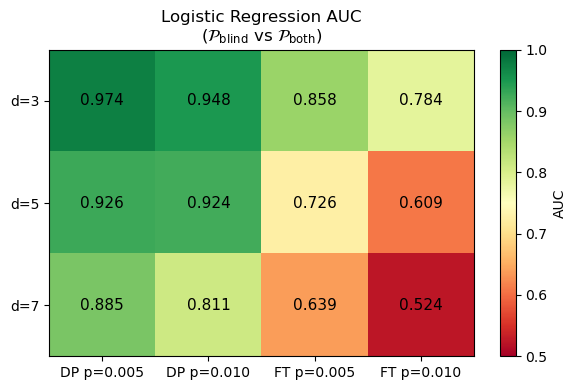

In [251]:
"""
    Figure 1: AUC heatmap across all 12 models.
    Rows = (noise model, p), Cols = d.
    AUC > 0.7 means blind spots are geometrically structured.
"""

r_labels = ['DP p=0.005', 'DP p=0.010', 'FT p=0.005', 'FT p=0.010']
c_labels = ['d=3', 'd=5', 'd=7']

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(auc_matrix, vmin=0.5, vmax=1.0, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax, label='AUC')

ax.set_xticks(range(4)); ax.set_xticklabels(r_labels)
ax.set_yticks(range(3)); ax.set_yticklabels(c_labels)
ax.set_title('Logistic Regression AUC\n'
            r'($\mathcal{P}_{\rm blind}$ vs $\mathcal{P}_{\rm both}$)')

for i in range(3):
    for j in range(4):
        ax.text(j, i, f'{auc_matrix[i,j]:.3f}', ha='center', va='center',
                fontsize=11, color='black')

    plt.tight_layout()
    plt.savefig('auc.png', dpi=200, bbox_inches='tight')
    #plt.show()

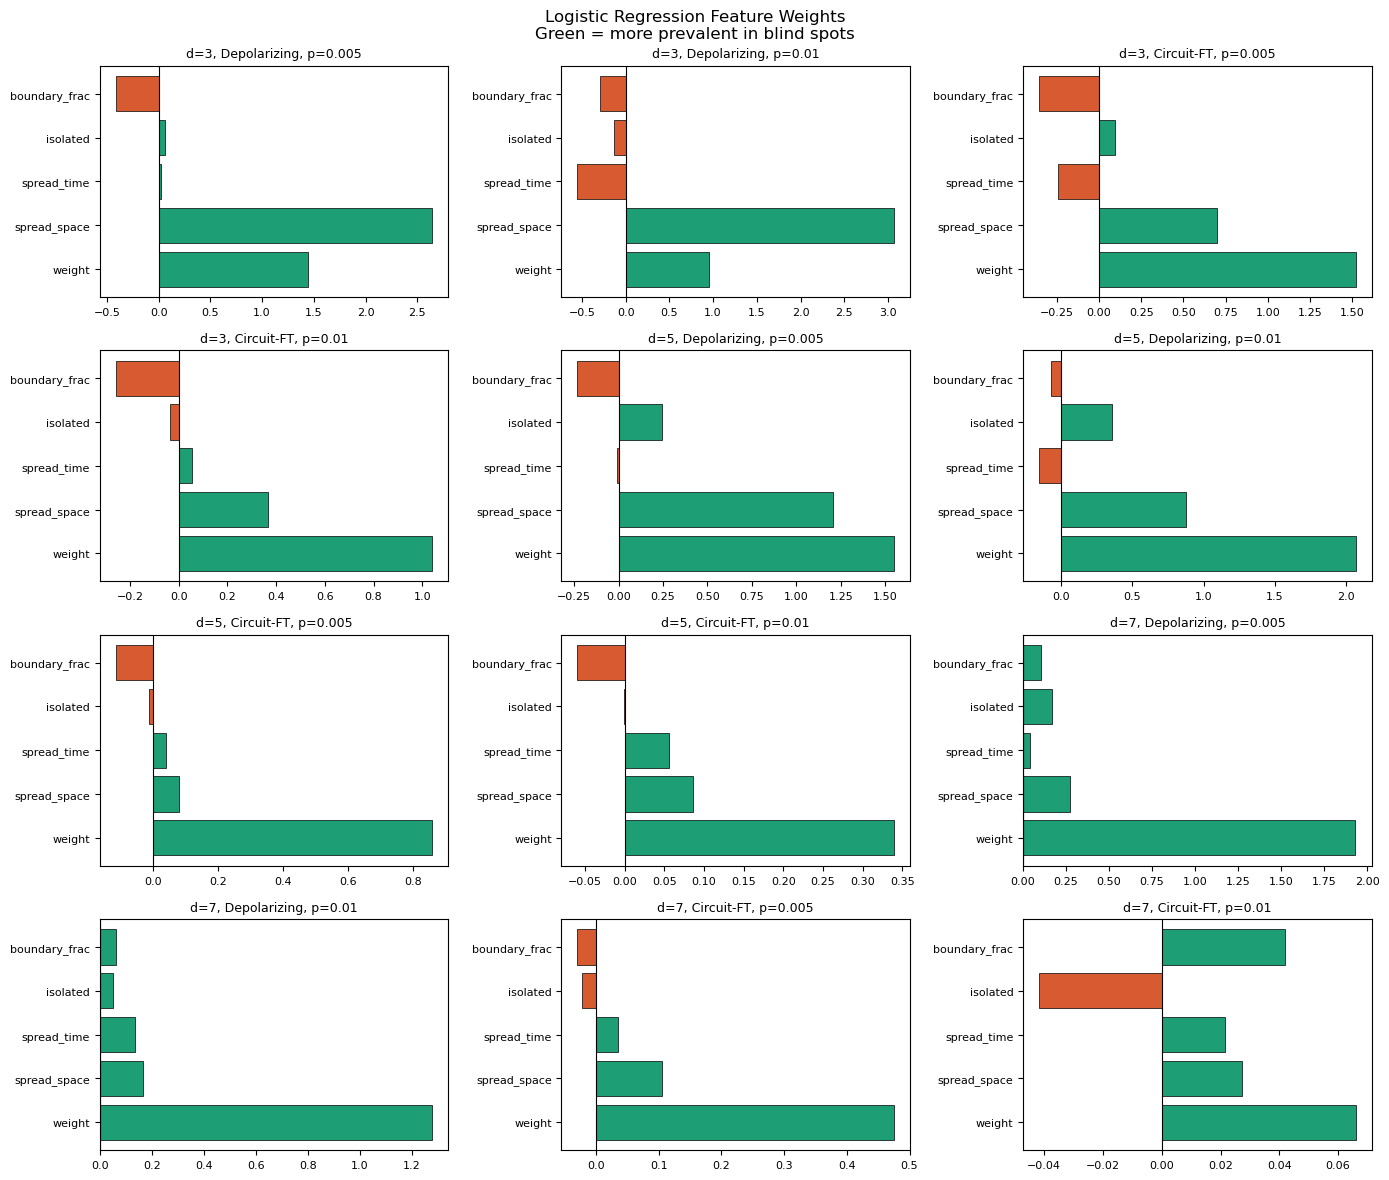

In [252]:
"""
Figure 2: Feature weight bar charts for all 12 models (4x3 grid).
Positive weight -> feature is higher in blind spots.
Negative weight -> feature is higher in correctly decoded syndromes.
"""
fig, axes = plt.subplots(4, 3, figsize=(14, 12), sharey=False)

for ax, (clf, scaler, (d, noise, p)) in zip(axes.flat, zip(clfs, scalers, MODEL_CONFIGS)):
    w = clf.coef_[0]
    bar_colors = ['#1D9E75' if wi >= 0 else '#D85A30' for wi in w]
    ax.barh(FEATURE_NAMES, w, color=bar_colors, edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'd={d}, {noise}, p={p}', fontsize=9)
    ax.tick_params(labelsize=8)

    fig.suptitle('Logistic Regression Feature Weights\n'
                 'Green = more prevalent in blind spots', fontsize=12)
plt.tight_layout()
   
plt.savefig('features.png', dpi=200, bbox_inches='tight')
   


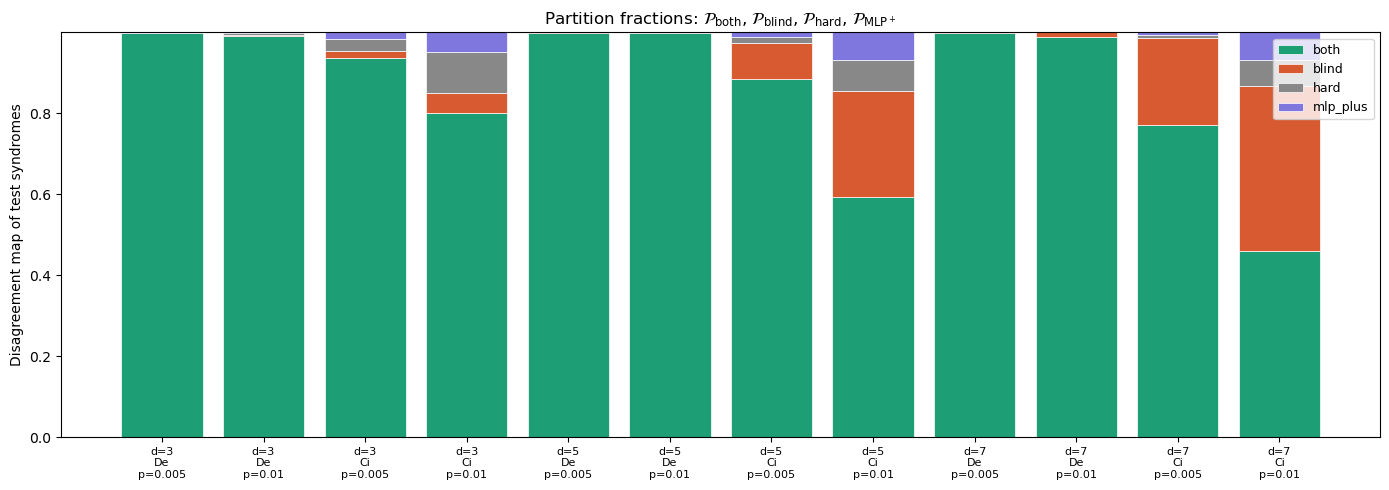

In [253]:
"""
Figure 3: Stacked bar chart of disagreement map across all 12 models.
"""
labels  = [f'd={d}\n{nm[:2]}\np={p}' for d, nm, p in MODEL_CONFIGS]
colors  = {'both': '#1D9E75', 'blind': '#D85A30',
                'hard': '#888888', 'mlp_plus': '#7F77DD'}
keys    = ['both', 'blind', 'hard', 'mlp_plus']

fracs = {k: [] for k in keys}
for part in d_map:
    for k in keys:
            if k == 'both' or k == 'blind':
                fracs[k].append(len(part[k]) / n_shots)
            else:
                 fracs[k].append(part[k])

fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(MODEL_CONFIGS))
for k in keys:
    ax.bar(range(len(MODEL_CONFIGS)), fracs[k], bottom=bottom,
            label=k, color=colors[k], edgecolor='white', linewidth=0.5)
    bottom += np.array(fracs[k])

ax.set_xticks(range(len(MODEL_CONFIGS)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Disagreement map of test syndromes')
ax.set_title(r'Partition fractions: $\mathcal{P}_{\rm both}$, '
                r'$\mathcal{P}_{\rm blind}$, $\mathcal{P}_{\rm hard}$, '
                r'$\mathcal{P}_{\rm MLP^+}$')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()

plt.savefig('d_map.png', dpi=200, bbox_inches='tight')
    